# Driving School Installs Prediction (SARIMAX)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
from utils import check_stationarity, plot_decomposition

warnings.filterwarnings("ignore")

## Hyperparameters & Config

In [2]:
DATA_CSV_FILE = "../../../data/ds_data_clean.csv"
TARGET_COL = "Daily User Installs"
EXOG_COLS = [
    "Daily Device Uninstalls",
    # "User to Device Ratio",
    "Daily User Uninstalls",
    "Active Device Installs",
    "Daily Average Rating",
    "Daily Crashes",
    "Daily ANRs",
    "Is Weekend",
]
TRAIN_RATIO = 0.8
SEASONAL_PERIOD = 7 # Weekly seasonality

## Loading Data

In [3]:
df = pd.read_csv(DATA_CSV_FILE)
df["Date"] = pd.to_datetime(df["Date"])
df["Is Weekend"] = (df["Date"].dt.dayofweek >= 5).astype(int)
df.set_index("Date", inplace=True)
df.sort_index(inplace=True)

y = df[TARGET_COL]
X = df[EXOG_COLS]

y.head()

Date
2019-09-02    2
2019-09-03    1
2019-09-04    2
2019-09-05    3
2019-09-06    6
Name: Daily User Installs, dtype: int64

## Seasonal Decomposition

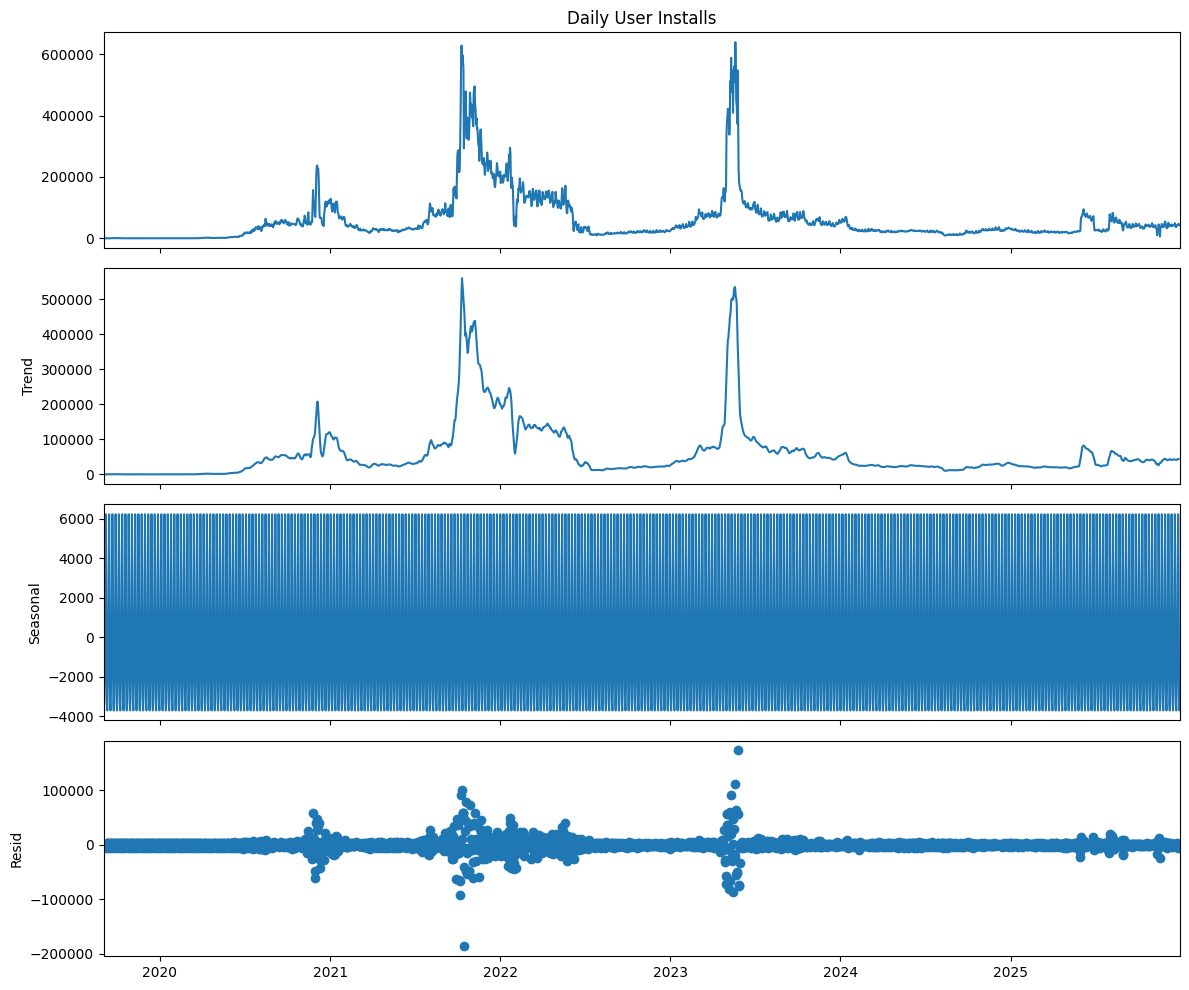

In [4]:
plot_decomposition(y, period=SEASONAL_PERIOD)

## Preprocessing and Temporal Split

In [5]:
train_size = int(len(df) * TRAIN_RATIO)
train_df = df.iloc[:train_size]
test_df  = df.iloc[train_size:]

y_train = train_df[TARGET_COL]
y_test  = test_df[TARGET_COL]
X_train = train_df[EXOG_COLS]
X_test  = test_df[EXOG_COLS]

print(f"Train: {train_df.index[0].date()} → {train_df.index[-1].date()}  ({len(y_train)} days)")
print(f"Test:  {test_df.index[0].date()} → {test_df.index[-1].date()}  ({len(y_test)} days)")

## Auto-ARIMA with Exogenous Variables

In [6]:
model_auto = auto_arima(
    y_train,
    X=X_train,
    seasonal=True,
    m=SEASONAL_PERIOD,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
)

print(model_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=38959.818, Time=2.83 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=41336.846, Time=0.19 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=39181.283, Time=1.23 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=40245.675, Time=1.14 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=53403.333, Time=0.18 sec
 ARIMA(2,0,2)(0,0,1)[7] intercept   : AIC=39051.528, Time=2.63 sec
 ARIMA(2,0,2)(1,0,0)[7] intercept   : AIC=39049.143, Time=2.04 sec
 ARIMA(2,0,2)(2,0,1)[7] intercept   : AIC=38965.605, Time=4.20 sec
 ARIMA(2,0,2)(1,0,2)[7] intercept   : AIC=38966.274, Time=6.16 sec
 ARIMA(2,0,2)(0,0,0)[7] intercept   : AIC=39060.384, Time=1.13 sec
 ARIMA(2,0,2)(0,0,2)[7] intercept   : AIC=39035.859, Time=5.03 sec
 ARIMA(2,0,2)(2,0,0)[7] intercept   : AIC=39030.359, Time=3.98 sec
 ARIMA(2,0,2)(2,0,2)[7] intercept   : AIC=38958.862, Time=5.92 sec
 ARIMA(1,0,2)(2,0,2)[7] intercept   : AIC=38994.468, Time=5.11 sec
 ARIMA(2,0,1)(2,0,2

## Fit Final SARIMAX Model

In [7]:
p, d, q = model_auto.order
P, D, Q, s = model_auto.seasonal_order

model = SARIMAX(
    y_train, 
    exog=X_train, 
    order=(p, d, q), 
    seasonal_order=(P, D, Q, s)
)
model_fit = model.fit(disp=False)
print(model_fit.summary())

                                       SARIMAX Results                                        
Dep. Variable:                    Daily User Installs   No. Observations:                 1850
Model:             SARIMAX(2, 0, 3)x(2, 0, [1, 2], 7)   Log Likelihood              -19459.261
Date:                                Mon, 30 Mar 2026   AIC                          38952.523
Time:                                        16:40:17   BIC                          39046.413
Sample:                                    09-02-2019   HQIC                         38987.134
                                         - 09-24-2024                                         
Covariance Type:                                  opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Daily Device Uninstalls          0   1.34e+04          0

## Rolling Forecast & Evaluation

------------------------------
SARIMAX EVALUATION RESULTS
------------------------------
RMSE: 17045.06 installs
MAE:  13888.22 installs
------------------------------


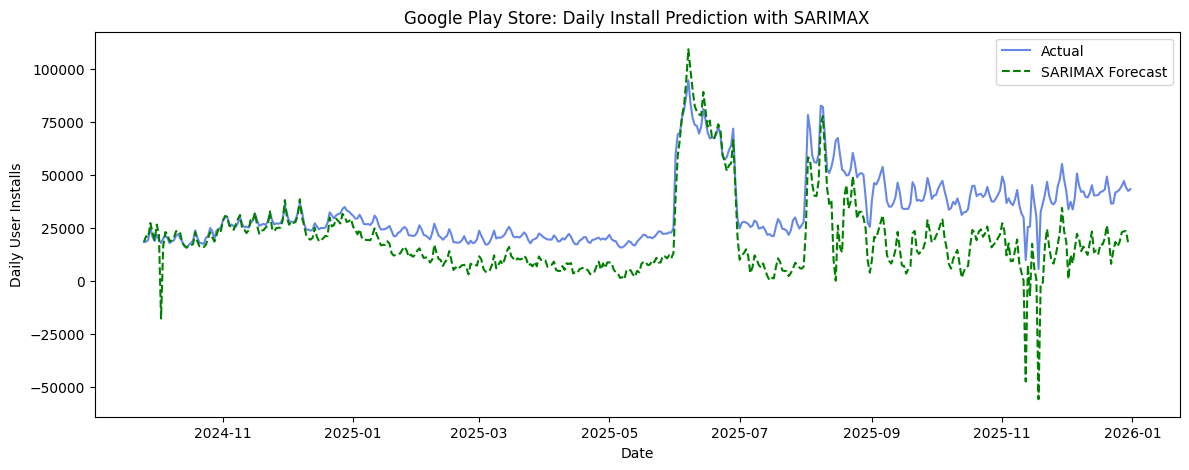

In [8]:
ROLL_PERIOD = 7  # re-fit every week, forecast 7 days ahead

# Walk-forward validation in weekly chunks:
# SARIMAX requires exogenous variables, so both history (endog) and
# the corresponding exog rows are tracked and sliced per chunk.
history_y = list(y_train.copy())
history_X = X_train.copy()          # DataFrame — append rows each chunk
rolling_preds = []

for start in range(0, len(y_test), ROLL_PERIOD):
    chunk_y = y_test.iloc[start : start + ROLL_PERIOD]
    chunk_X = X_test.iloc[start : start + ROLL_PERIOD]
    steps   = len(chunk_y)

    model_roll = SARIMAX(
        history_y,
        exog=history_X,
        order=(p, d, q),
        seasonal_order=(P, D, Q, s),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit_roll = model_roll.fit(disp=False)
    yhats    = fit_roll.forecast(steps=steps, exog=chunk_X)

    rolling_preds.extend(yhats)
    history_y.extend(chunk_y.tolist())           # reveal true endog
    history_X = pd.concat([history_X, chunk_X])  # reveal true exog

rolling_preds = pd.Series(rolling_preds, index=y_test.index)

rmse = np.sqrt(mean_squared_error(y_test, rolling_preds))
mae  = mean_absolute_error(y_test, rolling_preds)

print("-" * 30)
print("SARIMAX ROLLING FORECAST RESULTS")
print(f"  (re-fit every {ROLL_PERIOD} days)")
print("-" * 30)
print(f"RMSE: {rmse:.2f} installs")
print(f"MAE:  {mae:.2f} installs")
print("-" * 30)

plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test,         label="Actual",                         color="royalblue", alpha=0.8)
plt.plot(y_test.index, rolling_preds,  label=f"Rolling Forecast ({ROLL_PERIOD}d)", color="green",     linestyle="--")
plt.title(f"Google Play Store: Daily Install Prediction with SARIMAX (Rolling {ROLL_PERIOD}-Day)")
plt.xlabel("Date")
plt.ylabel("Daily User Installs")
plt.legend()
plt.tight_layout()
plt.show()

## Residual Analysis

In [ ]:
residuals = y_test - rolling_preds
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=50, color="lightcoral", edgecolor="black")
plt.axvline(0, color="black", linestyle="--")
plt.title("SARIMAX Rolling Forecast Residuals (Actual - Predicted)")
plt.show()

## Save Model

In [ ]:
import json

MODEL_SAVE_PATH = "sarimax_model.pkl"
META_SAVE_PATH  = "sarimax_model_meta.json"

# Save the final fitted model (trained on full training set)
model_fit.save(MODEL_SAVE_PATH)

# Save metadata alongside
meta = {
    "model":            "SARIMAX",
    "order":            list(model_auto.order),
    "seasonal_order":   list(model_auto.seasonal_order),
    "seasonal_period":  SEASONAL_PERIOD,
    "target_col":       TARGET_COL,
    "exog_cols":        EXOG_COLS,
    "train_ratio":      TRAIN_RATIO,
    "forecast_type":    "rolling_nstep",
    "roll_period_days": ROLL_PERIOD,
    "train_start":  str(train_df.index[0].date()),
    "train_end":    str(train_df.index[-1].date()),
    "test_start":   str(test_df.index[0].date()),
    "test_end":     str(test_df.index[-1].date()),
    "rmse": round(rmse, 4),
    "mae":  round(mae, 4),
}
with open(META_SAVE_PATH, "w") as f:
    json.dump(meta, f, indent=2)

print(f"Model saved    → {MODEL_SAVE_PATH}")
print(f"Metadata saved → {META_SAVE_PATH}")